# Project 2: Model Analysis Project

## Table of contents <a id='toc0_'></a>
- [Question 1: A Consumer with Two Nests](#toc1_)
    - [Question 1.1: The problem in nested budget shares](#toc1_1_)
    - [Question 1.2: Calibration](#toc1_2_)
    - [Question 1.3: How do you know your answer is right?](#toc1_3_)
- [Question 2: Solving the Model Numerically](#toc2_)
    - [Question 2.1: A Two-dimensional Grid Search](#toc2_1_)
    - [Question 2.2: L-BFGS-B](#toc2_2_)
- [Question 3: Relative prices and demand](#toc3_)

We import the nessesary packages and the two python files given in the project description:

In [1]:
%reload_ext autoreload

# Import consumer.py and government.py - vil i dog hellere sætte ind i vores egen?
from Consumer import ConsumerClass
from Government import GovernmentClass

# Import all necessary packages
import numpy as np
import pandas as pd
from scipy import optimize
from types import SimpleNamespace

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# The functions
import modelproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1: A Consumer with Two Nests <a id='toc1_'></a>

### Question 1.1: The problem in nested budget shares <a id='toc1_1_'></a>

To be able to start the project, we fill out the pass arguments in consumer.py, based on the model description. We have clearly marked in consumer.py where we change the code.

In [2]:
# we check whether the code runs smoothly after we have filled it in
#Print the parameters
model=ConsumerClass()
print(model)

#We know that with a CES function, inserting x1=x2=x3=1 means that utility should also be 1, as the function collapses:
assert np.isclose(model.utility(1.0,1.0,1.0), 1.0), 'utility(1,1,1) should be 1'
print(' \n utility sanity check passed')

#Could also add a check on whether corner solutions are stable??

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000
 
 utility sanity check passed


So we find that the code we have inserted in consumption.py runs smoothly and holds the basic values that we expected

### Question 1.2: Calibration <a id='toc1_2_'></a>

We now implement the two calibrations that we will use in the following questions, where only the substitution between the modes of transport differ (complements or substitutes respectively). To do this, we let model_comp be where $sigma_B=0.4$, so complements, and let model_sub have the value of $sigma_B=3.0$ so bus and train are substitutes.

In [3]:
model_comp = ConsumerClass()
model_sub  = ConsumerClass(par={'sigma_B':3.0})

print(model_comp)
print(model_sub)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


### Question 1.3: How do you know your answer is right? <a id='toc1_3_'></a>

#### Question 1.3.1

As we cannot check the solution for the model, we check whether the solutions are possible, meaning that the budget shares sum to 1 and are all positive.

In [4]:
#First, check if the solution is possible
for model in (model_comp, model_sub):
    sol = model.solve(do_print=False)
    assert 0 < sol.s1 < 1 and 0 < sol.s2 and 0 < sol.s3
    assert np.isclose(sol.s1+sol.s2+sol.s3, 1.0), 'the budget shares do not sum to one'

print('the answer is possible')

the answer is possible


#### Question 1.3.2

To check the answer, we compare the results we get from the model when solved using optimize.minimize and when we solve the model numerically in section 2. Here, we have inserted the grid-solution from section 2.

In [5]:
# Write code here...


We find that...

## Question 2: Solving the Model Numerically <a id='toc2_'></a>

### Question 2.1: A Two-dimensional Grid Search <a id='toc2_1_'></a>

#### Question 2.1.1

We make the grid of the N values in the consumer.py file in solve_grid - we now report the values the weigths and the three implied budget shares for each calibration.

In [6]:
print('when transport are complements:')
sol_grid_comp = model_comp.solve_grid()
print('when transport are substitutes:')
sol_grid_sub  = model_sub.solve_grid()

when transport are complements:
s1 = 0.5377, w = 0.4372, budget shares = (0.5377, 0.2021, 0.2602), u = 3.401601
when transport are substitutes:
s1 = 0.5377, w = 0.6935, budget shares = (0.5377, 0.3206, 0.1417), u = 3.485100


So we see that when the budget shares for train and bus are more equal when the modes of transport are complements, whereas when they are substitutes, more are spent on bus trips, and results in a higher utility for the consumer.

#### Question 2.1.2

We now plot the utility over the nested shares in a 3D plot and a contour plot with the solution shown for both calibrations:

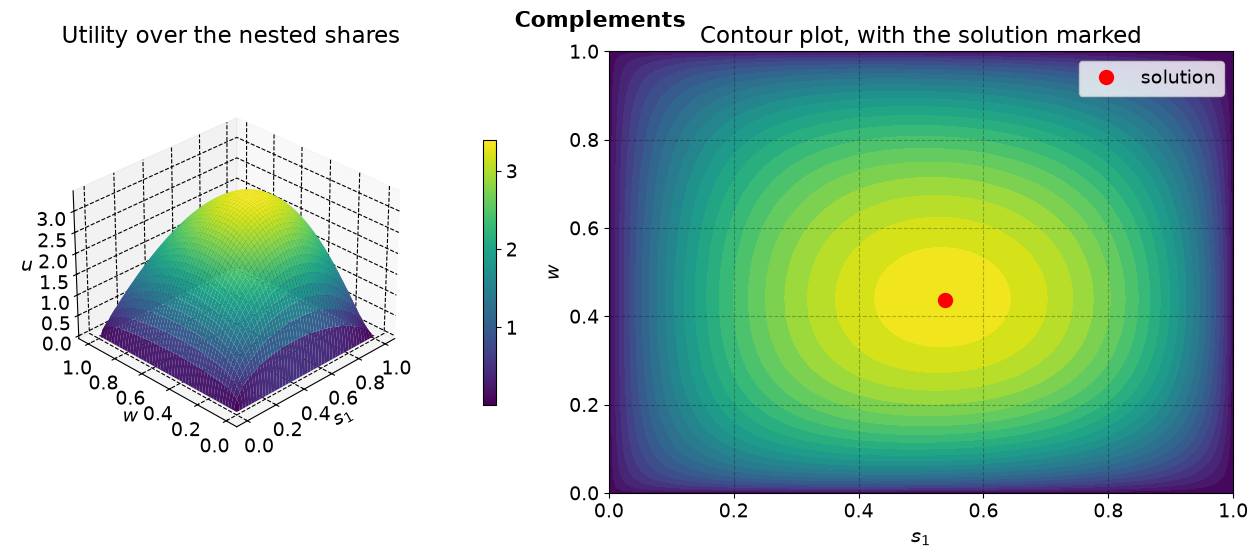

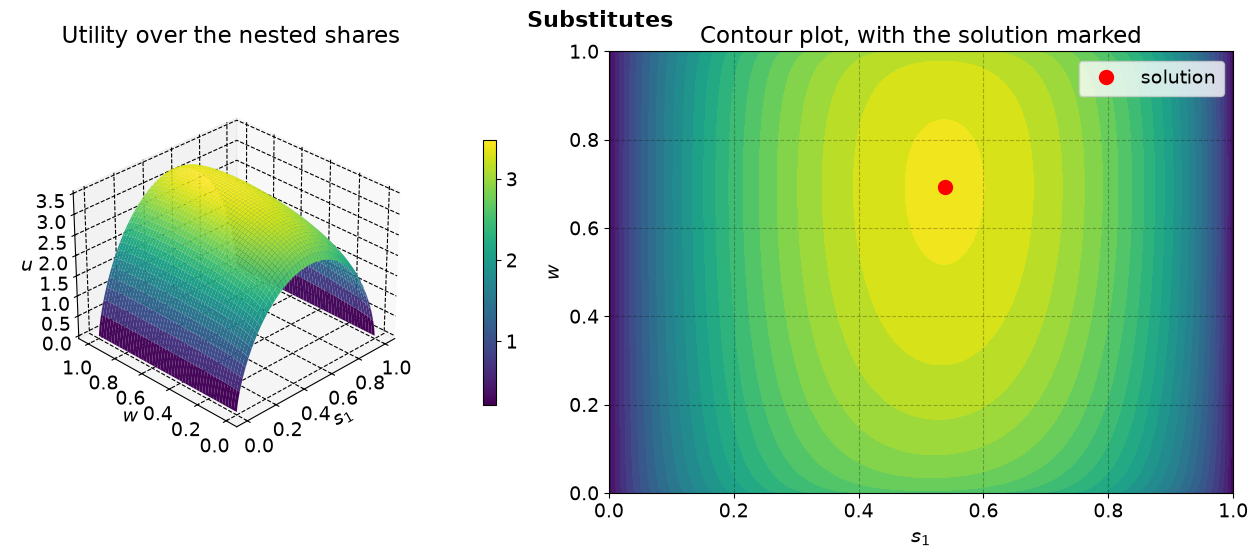

In [7]:
from matplotlib import cm # import the colormap
#Define the figure, so only have to write it out once:
#Because we need the contour plot for 2.2.2, we write it as a seperate function, then call it:

def plot_contour(sol, title, ax=None, path=None): #last two calls needed for 2.2.2
    if ax is None: #so the plot works for 2.1.2, without the ax call
        fig, ax = plt.subplots(figsize=(6.5,5.5))
    else:
        fig = ax.figure

    ax.contourf(sol.s1_grid, sol.w_grid, sol.u_grid, levels=30)
    ax.plot(sol.s1, sol.w, 'o', color='red', ms=10, label='solution')

    if path is not None:
        ax.plot(path[:,0], path[:,1], '-o', color='white', ms=4, lw=1.5, label='convergence path')

    ax.set_title(f'Contour plot, with the solution marked')
    ax.set_xlabel('$s_1$')
    ax.set_ylabel('$w$')
    ax.legend()

    return fig, ax

def plot_utility_surf(sol, title):
    fig = plt.figure(figsize=(13,5.5))

    #The 3d plot:
    ax1 = fig.add_subplot(1,2,1,projection='3d')
    surf = ax1.plot_surface(sol.s1_grid, sol.w_grid, sol.u_grid, cmap='viridis') #make sure the colourmap matches the utility values
    fig.colorbar(surf, ax=ax1, shrink=0.6)
    # labels and titles:
    fig.suptitle(title, fontsize=16, fontweight='bold')
    ax1.set_title('Utility over the nested shares')
    ax1.set_xlabel('$s_1$')
    ax1.set_ylabel('$w$')
    ax1.set_zlabel('$u$')
    #change the direction of the y-axis and where the z-axis is placed
    ax1.view_init(azim=-135,elev=30) 
    ax1.set_box_aspect([4,4,3],zoom=0.8)

    #and now the contour plot:
    ax2=fig.add_subplot(1,2,2)
    plot_contour(sol, title, ax=ax2)


    fig.tight_layout(pad=0.1)


plot_utility_surf(sol_grid_comp, 'Complements')

plot_utility_surf(sol_grid_sub, 'Substitutes')

So we see that when means of transportation are substitutes, the weight on the bus, w, is higher compared to when it is complements, as here the consumer wants to spread the weight on both trains and busses. We also see that the utility surface seem to be flatter for subsitutes, meaning that a wider array of w-values can lead to almost the same utility-value compared to when it is complements, where the utility surface is more pointed.

#### Question 2.1.3

We now test how sensitive the grid solving method is to the value of N, meaning how fine the grid is. The finer the grid, the more evaluations of u.

In [8]:
#for the 4 N-values and the two model calibrations:
N_values=[50, 100, 500, 1000]
models={'Complements': model_comp, 'Substitutes': model_sub}

results={}
for name, model in models.items():
    for N in N_values:
        opt=model.solve_grid(N=N, do_print=False)
        results[(name, N)]= opt
        print(f'{name}, N={N:4d}: s1={opt.s1:.4f}, w={opt.w:.4f}, u={opt.u:.6f}, evaluations={N*N}')
    print() 

#To see how much the answer moves, we look at the differences in s1, w and u, every time N becomes larger:
print('Changes in the nested budget share and the utility with a finer grid search')
for name in models:
    print(name)
    for N_prev, N in zip(N_values, N_values[1:]):
        opt_prev = results[(name,N_prev)]
        opt = results[(name,N)]
        print(f'  N={N:4d}: Δs1={abs(opt.s1-opt_prev.s1):.5f}, Δw={abs(opt.w-opt_prev.w):.5f}, Δu={abs(opt.u-opt_prev.u):.6f}')


Complements, N=  50: s1=0.5306, w=0.4490, u=3.400748, evaluations=2500
Complements, N= 100: s1=0.5354, w=0.4444, u=3.401482, evaluations=10000
Complements, N= 500: s1=0.5351, w=0.4389, u=3.401674, evaluations=250000
Complements, N=1000: s1=0.5355, w=0.4394, u=3.401680, evaluations=1000000

Substitutes, N=  50: s1=0.5306, w=0.6939, u=3.484594, evaluations=2500
Substitutes, N= 100: s1=0.5354, w=0.6970, u=3.485005, evaluations=10000
Substitutes, N= 500: s1=0.5391, w=0.6914, u=3.485097, evaluations=250000
Substitutes, N=1000: s1=0.5385, w=0.6927, u=3.485104, evaluations=1000000

Changes in the nested budget share and the utility with a finer grid search
Complements
  N= 100: Δs1=0.00474, Δw=0.00454, Δu=0.000734
  N= 500: Δs1=0.00028, Δw=0.00557, Δu=0.000192
  N=1000: Δs1=0.00047, Δw=0.00056, Δu=0.000005
Substitutes
  N= 100: Δs1=0.00474, Δw=0.00309, Δu=0.000411
  N= 500: Δs1=0.00372, Δw=0.00559, Δu=0.000092
  N=1000: Δs1=0.00054, Δw=0.00131, Δu=0.000006


We see that the number of evaluations of u grows quadratically with N, since the grid search evaluates every point on an N×N grid. With a finer grid, the answer does move, and the answer improves smoothly: it becomes more accurate as the grid gets finer, but only slightly once N is already large. This higher accuracy comes at a high computational cost, since the number of evaluations grows rapidly with N. Comparing the two calibrations, the improvement in u with a finer grid is small for both, but the improvement in w converges more slowly for substitutes than for complements. As we saw in 2.1.2, many w-values give almost the same u-value under substitutes (flatter utility surface), so the grid search converges more slowly onto the exact best w — even though the resulting utility is still accurate.

#### Question 2.1.4

All in all, we find that for both calibrations the surface is steep along the s1-direction (food), so there is a high cost to utility when moving food away from optimum. However, in the w-direction, the two different calibrations are quite different where the surface is steep when means of transportation are complements, indicating a peak around the optimum. For substitutes, the surface is more flat in the w-direction, indication a more flat plateau around optimum. Therefore we expect that it is harder for an optimizer to find the answer when busses and trains are substitutes, as the utility only changes slightly for different w-values when close to optimum, making it harder to find out what direction improves utility. This was shown very clearly in 2.1.3, where the improvement in w converged more slowly for subsitutes than for complements as the grid was refined.

### Question 2.2: L-BFGS-B <a id='toc2_2_'></a>

#### Question 2.2.1

We implement the L-BFGS-B solution in the consumer.py file, calling it solve. We compare the solution, the number of function evaluations and the running time with the grid search, that we made in 2.1    

In [9]:
# We import time, and run the solutions for both model calibration.
import time
sol_min_comp = model_comp.solve(do_print=False)
sol_min_sub  = model_sub.solve(do_print=False)
models = {'Complements': model_comp, 'Substitutes': model_sub}

for name, model in models.items():
    print(f'--{name}--')

    # grid search
    t0 = time.perf_counter()
    sol_grid = model.solve_grid(do_print=False) 
    t_grid = time.perf_counter() - t0

    # L-BFGS-B
    t0 = time.perf_counter()
    sol_min = model.solve(do_print=False)
    t_min = time.perf_counter() - t0


    print(f'  grid search: s1={sol_grid.s1:.4f}, w={sol_grid.w:.4f}, u={sol_grid.u:.6f}, '
          f'evaluations=40000, time={t_grid:.4f}s') # evaluations are 40.000 since N=200 if we do not change it
    print(f'  L-BFGS-B:    s1={sol_min.s1:.4f}, w={sol_min.w:.4f}, u={sol_min.u:.6f}, '
          f'evaluations={sol_min.res.nfev}, time={t_min:.4f}s')
    print()



--Complements--
  grid search: s1=0.5377, w=0.4372, u=3.401601, evaluations=40000, time=0.0043s
  L-BFGS-B:    s1=0.5356, w=0.4395, u=3.401680, evaluations=18, time=0.0015s

--Substitutes--
  grid search: s1=0.5377, w=0.6935, u=3.485100, evaluations=40000, time=0.0042s
  L-BFGS-B:    s1=0.5382, w=0.6923, u=3.485105, evaluations=27, time=0.0022s



So we find that the methods find slightly different solutions (but agree at least on the first two decimals), and that the grid search takes slightly longer, with a much higher count of evaluations. So the two methods do converge towards the same answer, but they do not agree. This is because the grid is 200 x 200, and therefore perhaps not fine enough. We also see that L-BFGS-B needs only few evaluations, because it uses a quasi-Newton method with bounds - this is a lot more targeted than the grid search.

#### Question 2.2.2

We now record the convergence path, seeing how the quasi-Newton method with bounds find the answer. We plot this in the contour plot we made in 2.1.2 but also plot how far each of the iterations are from the solving-point on a log-scaled iteration:

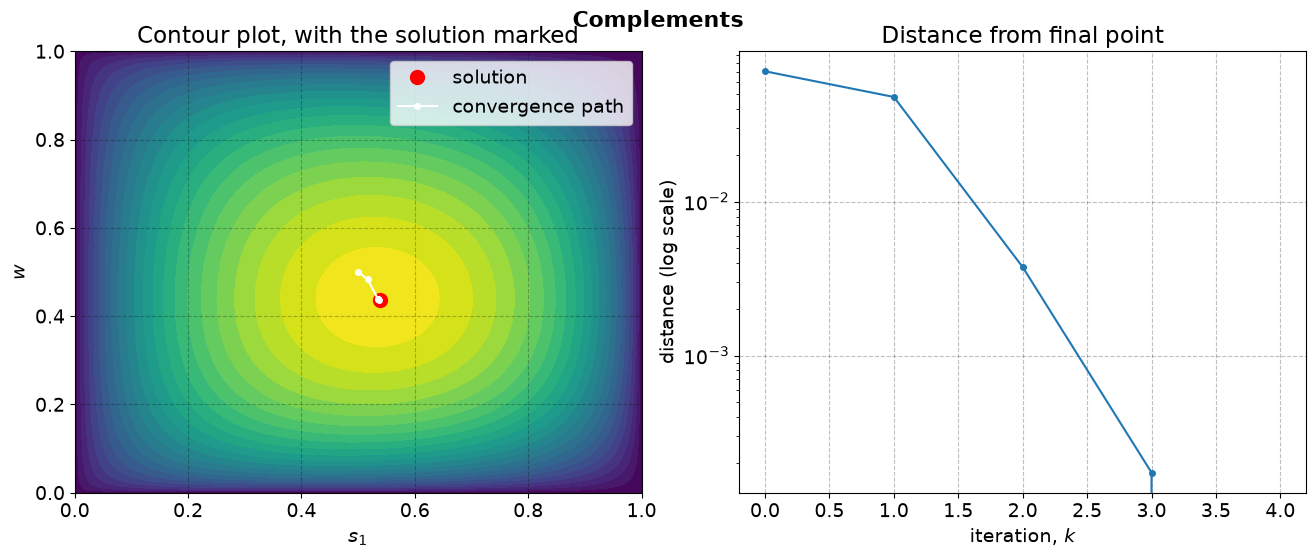

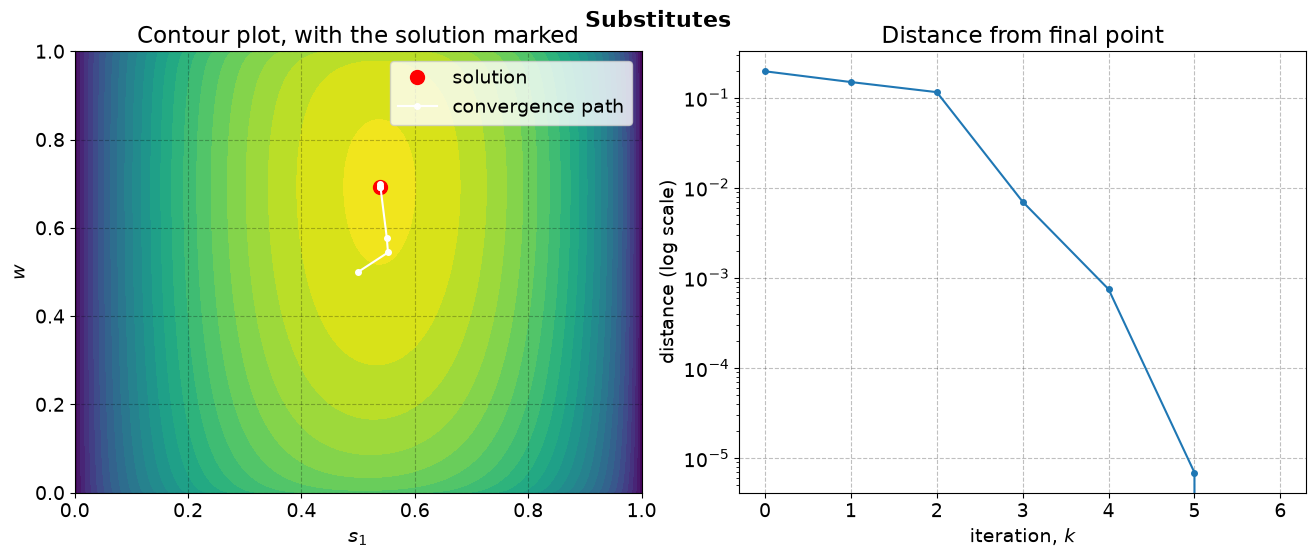

In [10]:
#Define a figure with both plots:
def plot_convergence_full(sol_grid, sol_min, title):

    fig = plt.figure(figsize=(13,5.5))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # contour plot with the solve path overlaid
    ax1 = fig.add_subplot(1,2,1)
    plot_contour(sol_grid, title, ax=ax1, path=sol_min.path)

    # distance from the final point, using a log scale
    ax2 = fig.add_subplot(1,2,2)
    path = sol_min.path
    final = path[-1] # so the last value in path
    distances = np.linalg.norm(path - final, axis=1)

    ax2.plot(distances, '-o', ms=4)
    ax2.set_yscale('log')
    ax2.set_title(f'Distance from final point')
    ax2.set_xlabel('iteration $k$')
    ax2.set_ylabel('distance (log scale)')

    fig.tight_layout(pad=0.1)

plot_convergence_full(sol_grid_comp, sol_min_comp, 'Complements')

plot_convergence_full(sol_grid_sub, sol_min_sub, 'Substitutes')

So we see that convergence is slower for substitutes in the beginning, and then the distance gets smaller very quickly. For complements, the convergence is quicker. The method is for both especially quick after the first iteration. We also see that the method is closer to the final answer from the first iteration.

#### Question 2.2.3

We now solve from 6 different starting points by calling solve with different starting point $s_0$. The starting point has for all solved been $[1/2, 1/2]$, so we print that again and now do the four corners plus a random point:

In [11]:
print(f'  s_0=(0.5, 0.5):    s1={sol_min.s1:.4f}, w={sol_min.w:.4f}, u={sol_min.u:.6f}, '
 f'evaluations={sol_min.res.nfev}, time={t_min:.4f}s')

starts=[(0,0),(0,1),(1,0),(1,1),(0.66,1)]


ConsumerClass	 GovernmentClass	 N	 N_prev	 N_values	 SimpleNamespace	 cm	 colors	 model	 
model_comp	 model_sub	 modelproject	 models	 name	 np	 opt	 opt_prev	 optimize	 
pd	 plot_contour	 plot_convergence_full	 plot_utility_surf	 plt	 results	 sol	 sol_grid	 sol_grid_comp	 
sol_grid_sub	 sol_min	 sol_min_comp	 sol_min_sub	 t0	 t_grid	 t_min	 time	 


We find that...

#### Question 2.2.4

We look at...

In [12]:
# Write code here...

We find that...

#### Question 2.2.5

We look at...

In [13]:
# Write code here...

We find that...

## Question 3: Relative prices and demand <a id='toc3_'></a>

#### Question 3.3.1

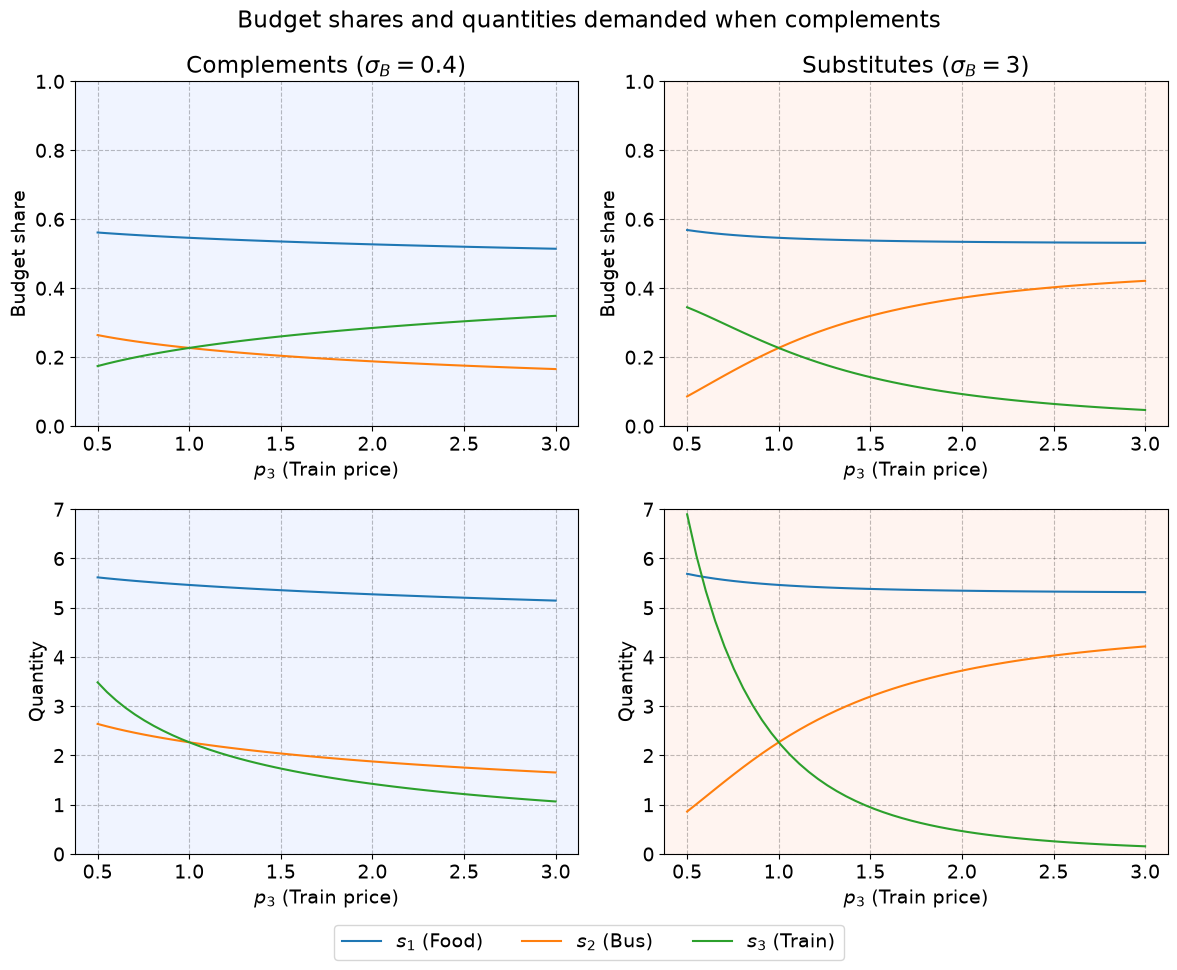

In [14]:
# A. Finding the optimal budget shares and quantities across a range of prices, p3

# i. A range of numbers from 0.5 to 3.0
price3_range = np.linspace(0.5,3,50)

# ii. Solving the model assuming compliments across this range of p3's
resultscomp = [] # empty container for results
for p3 in price3_range:
    model_comp.par.p3 = p3
    sol = model_comp.solve(do_print=False)

    s1, s2, s3 = model_comp.shares(sol.s1, sol.w) # saving optimal shares
    x1, x2, x3 = model_comp.quantities(sol.s1, sol.w) # saving optimal quantities

    resultscomp.append({ # appending these in dictionary "results"
        'p3': p3,
        's1': s1, 's2': s2, 's3': s3,
        'x1': x1, 'x2': x2, 'x3': x3,
    })

df_C = pd.DataFrame(resultscomp)

# ii. Solving the model assuming substitutes across this range of p3's
resultssub = [] # empty container for results
for p3 in price3_range:
    model_sub.par.p3 = p3
    sol = model_sub.solve(do_print=False)

    s1, s2, s3 = model_sub.shares(sol.s1, sol.w) # saving optimal shares
    x1, x2, x3 = model_sub.quantities(sol.s1, sol.w) # saving optimal quantities

    resultssub.append({ # appending these in dictionary "results"
        'p3': p3,
        's1': s1, 's2': s2, 's3': s3,
        'x1': x1, 'x2': x2, 'x3': x3,
    })

df_S = pd.DataFrame(resultssub)


# B. Plotting budget share and quantities

# i. Setting up a figure with 2x2 panels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Budget shares and quantities demanded when complements')

# ii. Plotting the budget shares across p3-values for model assuming complements
ax = axes[0,0]
ax.plot(df_C['p3'], df_C['s1'], label='$s_1$ (Food)')
ax.plot(df_C['p3'], df_C['s2'], label='$s_2$ (Bus)')
ax.plot(df_C['p3'], df_C['s3'], label='$s_3$ (Train)')
ax.set_xlabel('$p_3$ (Train price)')
ax.set_ylabel('Budget share')
ax.set_ylim(0,1)
ax.set_title('Complements ($\\sigma_B=0.4$)')

# iii. Plotting the quantities across p3-values for model assuming complements
ax = axes[1,0]
ax.plot(df_C['p3'], df_C['x1'], label='$x_1$ (Food)')
ax.plot(df_C['p3'], df_C['x2'], label='$x_2$ (Bus)')
ax.plot(df_C['p3'], df_C['x3'], label='$x_3$ (Train)')
ax.set_xlabel('$p_3$ (Train price)')
ax.set_ylabel('Quantity')
ax.set_ylim(0,7)

# iv. Plotting the budget shares across p3-values for model assuming substitutes
ax = axes[0,1]
ax.plot(df_S['p3'], df_S['s1'], label='$s_1$ (Food)')
ax.plot(df_S['p3'], df_S['s2'], label='$s_2$ (Bus)')
ax.plot(df_S['p3'], df_S['s3'], label='$s_3$ (Train)')
ax.set_xlabel('$p_3$ (Train price)')
ax.set_ylabel('Budget share')
ax.set_ylim(0,1)
ax.set_title(('Substitutes ($\\sigma_B=3$)'))

# v. Plotting the quantities across p3-values for model assuming substitutes
ax = axes[1,1]
ax.plot(df_S['p3'], df_S['x1'], label='$x_1$ (Food)')
ax.plot(df_S['p3'], df_S['x2'], label='$x_2$ (Bus)')
ax.plot(df_S['p3'], df_S['x3'], label='$x_3$ (Train)')
ax.set_xlabel('$p_3$ (Train price)')
ax.set_ylabel('Quantity')
ax.set_ylim(0,7)


# vi. Fixing legend box to a single positioned at center bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02))

# vii. Fixing background color for left and right column respectively to highlight that 
# left side panels are from complement model and right side panels are from substitute model
for ax in axes[:, 0]:  # hele venstre kolonne
    ax.set_facecolor('#f0f4ff')   # meget lys blå

for ax in axes[:, 1]:  # hele højre kolonne
    ax.set_facecolor('#fff4f0')   # meget lys orange

# viii. Pushing panels upwards to make room for legend box 
fig.tight_layout(rect=[0, 0.06, 1, 1])

plt.show()


#### Question 3.3.2

The figure above shows that the budget share of train travel (the green line in the upper panels) *increases* with the price of trains, $p_3$, in the model assuming complements (left panel), while it *decreases* with $p_3$ in the model assuming substitutes (right panel).

This difference arises because the substitution effect dominates the income effect, as explained in more detail in the answer to the question below.

#### Question 3.3.3

As the price of trains, $p_3$, increases, the number of bus trips (orange line in the lower panels) *decreases* in the model assuming complements (left side). Since complementary goods are, by definition, poor substitutes for each other, the consumer does not substantially substitute away from train tickets when their price increases. Instead, the consumer continues to purchase train tickets, as also reflected in the increasing budget share spent on trains in the panel above.

The decrease in bus quantities therefore arises because the income effect dominates the substitution effect. Although the higher price of train tickets creates some incentive to substitute towards bus trips, the consumer has less income available for purchasing bus tickets. Consequently, the income effect outweighs the substitution effect, resulting in an overall decrease in the quantity of bus tickets purchased.

The opposite pattern can be observed in the right-hand panel, where trains and buses are assumed to be substitutes. Here, higher train prices lead to an *increase* in the quantity of bus tickets purchased. While the income effect of higher train prices again reduces the consumer’s purchasing power and therefore pushes towards fewer bus trips, the substitution effect is stronger because trains and buses are highly substitutable. As a result, the substitution effect dominates, leading to an increase in the quantity of bus tickets purchased.

#### Question 3.3.4

From the lower panels, it can be seen that there are very few differences between the models in how the demand for food changes as the train ticket price, $p_3$, rises.

This is because the elasticity of substitution between food and travel, $\sigma_A$, is fixed across the two models, while most of the effect of the price change is absorbed within the transport nest. As the relative price of transportation changes, the quantity of food purchased therefore changes only slightly. The non-zero change in food demand is driven by the income effect. As discussed above, this effect is stronger when buses and trains are complements, causing the quantity of food purchased to fall slightly more in the model with complementary goods. However, the overall effect remains small due to the nested structure of the utility function. Since buses and trains form a separate nested bundle, the effect of the price change is primarily absorbed within this bundle through changes in the quantities of train and bus trips purchased.

Comparing the change in food demand with the change in bus demand further illustrates the importance of the nested structure. Food is outside the transport nest, whereas bus travel is part of it, and the two therefore respond quite differently to the change in the train price. If the elasticity of substitution between food and transport, $\sigma_A$, were larger, a greater share of the price effect would instead be absorbed through changes in food consumption.

## Question 4: Lump-sum taxes and product taxes <a id='toc3_'></a>

#### Question 4.3.1

We start by 